In [2]:
from matplotlib import pyplot as plt
import numpy as np


In [3]:
import MDAnalysis as mda


In [4]:
print("Using MDAnalysis version", mda.__version__)

Using MDAnalysis version 2.10.0


## analisis estructura inicial

In [5]:
u=mda.Universe('adk.psf','adk.pdb')


/opt/anaconda3/envs/nanociencia/lib/python3.14/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


In [6]:
print(u)


<Universe with 3341 atoms>


In [7]:
print(u.residues)

<ResidueGroup [<Residue MET, 1>, <Residue ARG, 2>, <Residue ILE, 3>, ..., <Residue ILE, 212>, <Residue LEU, 213>, <Residue GLY, 214>]>


In [8]:
u.atoms

<AtomGroup with 3341 atoms>

In [9]:
last_five = u.atoms[-5:]
print(last_five)


<AtomGroup [<Atom 3337: HA1 of type 6 of resname GLY, resid 214 and segid 4AKE>, <Atom 3338: HA2 of type 6 of resname GLY, resid 214 and segid 4AKE>, <Atom 3339: C of type 32 of resname GLY, resid 214 and segid 4AKE>, <Atom 3340: OT1 of type 72 of resname GLY, resid 214 and segid 4AKE>, <Atom 3341: OT2 of type 72 of resname GLY, resid 214 and segid 4AKE>]>


In [10]:
print(u.select_atoms('resname GLU'))

<AtomGroup [<Atom 318: N of type 54 of resname GLU, resid 22 and segid 4AKE>, <Atom 319: HN of type 1 of resname GLU, resid 22 and segid 4AKE>, <Atom 320: CA of type 22 of resname GLU, resid 22 and segid 4AKE>, ..., <Atom 3271: OE2 of type 72 of resname GLU, resid 210 and segid 4AKE>, <Atom 3272: C of type 20 of resname GLU, resid 210 and segid 4AKE>, <Atom 3273: O of type 70 of resname GLU, resid 210 and segid 4AKE>]>


In [14]:
print(u.atoms[:20].names) #et dona la llista de noms dels ultims atoms

print(u.atoms[:20].charges) #et dona les carregues

print(u.atoms[:20].masses) #et dona les masses

['N' 'HT1' 'HT2' 'HT3' 'CA' 'HA' 'CB' 'HB1' 'HB2' 'CG' 'HG1' 'HG2' 'SD'
 'CE' 'HE1' 'HE2' 'HE3' 'C' 'O' 'N']
[-0.30000001  0.33000001  0.33000001  0.33000001  0.20999999  0.1
 -0.18000001  0.09        0.09       -0.14        0.09        0.09
 -0.09       -0.22        0.09        0.09        0.09        0.50999999
 -0.50999999 -0.47      ]
[14.007  1.008  1.008  1.008 12.011  1.008 12.011  1.008  1.008 12.011
  1.008  1.008 32.06  12.011  1.008  1.008  1.008 12.011 15.999 14.007]


In [17]:
ca = u.select_atoms('resid 1-5 and name CA')#selecciono els atoms del 1 al 5 i amb residus CA
print(ca.positions) #TOTES LES POSICIONS DE TOTS ELS CARBONIS ALPHA DEL 1 AL 5
print(ca.center_of_mass())
print(ca.positions.shape)

[[11.665  8.393 -8.983]
 [11.415  5.434 -6.513]
 [ 8.96   5.613 -3.613]
 [ 8.29   3.076 -0.797]
 [ 5.011  3.764  1.13 ]]
[ 9.06820002  5.2559999  -3.75519994]
(5, 3)


In [27]:
hnh = u.atoms[[1, 0, 2]] #hem de escriure els atoms amb la forma que volem mesurar el angle, vertex-mig-vertex
print(hnh.names)

['HT1' 'N' 'HT2']


In [29]:
print(hnh.angle.value())

106.18631394383382


## analisis de trajectoria 

In [32]:
u=mda.Universe('adk.psf','unfolding.dcd')

/opt/anaconda3/envs/nanociencia/lib/python3.14/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [33]:
print(len(u.trajectory))


98


In [34]:
print(u.trajectory)

<DCDReader unfolding.dcd with 98 frames of 3341 atoms>


In [35]:
print (u.trajectory.time)

0.0


In [36]:
for ts in u.trajectory:
    time = u.trajectory.time
    rgyr = u.atoms.radius_of_gyration()
    print(f"Frame: {ts.frame:3d}, Time: {time:4.0f} ps, Rgyr: {rgyr:.4f} A")

Frame:   0, Time:    0 ps, Rgyr: 16.6690 A
Frame:   1, Time:    1 ps, Rgyr: 16.6732 A
Frame:   2, Time:    2 ps, Rgyr: 16.7315 A
Frame:   3, Time:    3 ps, Rgyr: 16.7223 A
Frame:   4, Time:    4 ps, Rgyr: 16.7440 A
Frame:   5, Time:    5 ps, Rgyr: 16.7185 A
Frame:   6, Time:    6 ps, Rgyr: 16.7741 A
Frame:   7, Time:    7 ps, Rgyr: 16.7764 A
Frame:   8, Time:    8 ps, Rgyr: 16.7894 A
Frame:   9, Time:    9 ps, Rgyr: 16.8289 A
Frame:  10, Time:   10 ps, Rgyr: 16.8521 A
Frame:  11, Time:   11 ps, Rgyr: 16.8549 A
Frame:  12, Time:   12 ps, Rgyr: 16.8723 A
Frame:  13, Time:   13 ps, Rgyr: 16.9108 A
Frame:  14, Time:   14 ps, Rgyr: 16.9494 A
Frame:  15, Time:   15 ps, Rgyr: 16.9810 A
Frame:  16, Time:   16 ps, Rgyr: 17.0033 A
Frame:  17, Time:   17 ps, Rgyr: 17.0196 A
Frame:  18, Time:   18 ps, Rgyr: 17.0784 A
Frame:  19, Time:   19 ps, Rgyr: 17.1265 A
Frame:  20, Time:   20 ps, Rgyr: 17.1491 A
Frame:  21, Time:   21 ps, Rgyr: 17.1759 A
Frame:  22, Time:   22 ps, Rgyr: 17.2168 A
Frame:  23,

In [64]:
rgyr = []
time = []
protein = u.select_atoms("protein")
for ts in u.trajectory:
    time.append(u.trajectory.time)
    rgyr.append(protein.radius_of_gyration())

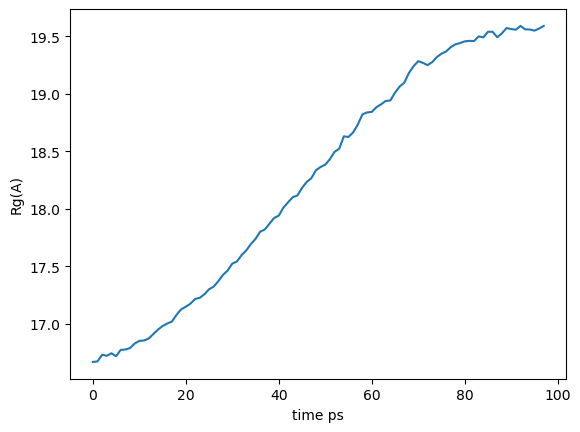

In [65]:
plt.plot(time,rgyr)
plt.xlabel('time ps')
plt.ylabel('Rg(A)')
plt.show()

In [69]:
#podem guardar les dades en un fitxer
fitxer=open('Rg.dat','w') #posem el nom del fitxer, i despres la w es w de write, de escriure en el fitxer


In [70]:
for i in range (len(time)):
    fitxer.write(f'{round(time[i],1)} {round(rgyr[i],2)}\n') #lo de \n es algo raro de que cada fila sigui un numero en concret

In [71]:
fitxer.close()